In [151]:
#while,it's very bad

In [1]:
import numpy as np
import pandas as pd

In [62]:
# 设置随机种子
np.random.seed(42)

# 生成400个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})


In [63]:
rng_divide=np.random.default_rng(17)

data_train=data.sample(frac=0.67,random_state=rng_divide)
data_test=data.sample(frac=0.33)
data_train.head()

,area,bedrooms,age,location,price
186,172.583330,1,11.660427,6.300838,225.989540
365,107.915396,3,17.035674,7.676982,187.310738
26,79.951067,3,4.251771,5.835698,171.990341
39,116.022874,1,10.003908,9.601881,190.966033
281,100.699274,2,0.936636,9.499153,211.037258


In [64]:
#normalize
Mean=data_train.mean(axis=0)
Std=data_train.std(axis=0)
dataTrain_normalized=(data_train-Mean)/Std  #can be optimized
dataTrain_normalized.head()

,area,bedrooms,age,location,price
186,1.123428,-1.748388,0.232495,0.126271,0.238032
365,-0.307932,0.280045,0.803037,0.843644,-0.588638
26,-0.926894,0.280045,-0.553880,-0.116203,-0.916077
39,-0.128481,-1.748388,0.056667,1.847079,-0.510515
281,-0.467653,-0.734172,-0.905757,1.793528,-0.081539


In [39]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
    

In [40]:
def get_loss(y,y_hat):
    return 1/2*pow((y_hat-y),2)

In [41]:
def upgrade_parameter(y,y_hat,x,level_1_to_2,\
              primary_parameter,alph=1):
    
    
    g=y_hat-y
    delta_power2=-alph*g*level_1_to_2
    delta_threshold2=-alph*g

    e=level_1_to_2*(1-level_1_to_2)*primary_parameter['power2']*g    #对后两项，我这里只是一维的输出，power2是1*7的
    delta_power1=-alph*x.reshape(-1,1)@e.reshape(1,-1)    #e,xi都是向量，最后会做成一个4*7的
    delta_threshold1=-alph*(-e)

    primary_parameter['power2']+=delta_power2
    primary_parameter['threshold2']+=delta_threshold2
    primary_parameter['power1']+=delta_power1
    primary_parameter['threshold1']+=delta_threshold1

    return primary_parameter


In [70]:
def rf_standard_BP(data,primary_parameter,loop):
    x=data.iloc[:-1].values
    y=data.iloc[-1]
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
    

    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
    
    y_hat=level_2+primary_parameter['threshold2'][0]    #why ?  #because array([1]) is not array(1)

    global rf_loss_sum  ###GLOBAL!!
    if loop%1500==0:
        rf_loss_sum+=get_loss(y,y_hat)
        print(f'mean loss:{(rf_loss_sum/((loop/1500)+1)):.6f}')

    primary_parameter=\
    upgrade_parameter(y,y_hat,x,level_1_to_2,\
                      primary_parameter,alph=0.1)
    
    return primary_parameter   

In [86]:
def rf_test_standardBP(data_test,primary_parameter):
    x=data_test.values
    
    
    #input to level1
    level_1=x@primary_parameter['power1'] #向量，直接计算了内积
    #deal and output
    level_1_to_2=sigmoid(level_1-primary_parameter['threshold1'])
   
    #input to level2
    level_2=level_1_to_2@primary_parameter['power2']
    #deal and output
    
   
    y_hat=level_2+primary_parameter['threshold2'][0]

    return y_hat

In [142]:
rf_loss_sum=0
rng=np.random.default_rng(17)
learner=15
rf_train_len=len(dataTrain_normalized)
rf_dict_parameter={}

all_columns=list(data_train.columns)
columns=all_columns[:-1]
len_columns=len(columns)
seleceSize=round(np.log(len_columns)/np.log(2))
#print(len_columns)

for t in range(learner):  
    print(f"learner {t}")
    rf_loss_sum=0
    columns_selected=rng.choice(columns,seleceSize,replace=False).tolist()
    dataTrain_selectColumns=dataTrain_normalized.loc[:,columns_selected]
    dataTrain_y=dataTrain_normalized.iloc[:,-1]
    dataTrain_selected=pd.concat([dataTrain_selectColumns,dataTrain_y],axis=1)
    
    rf_train=dataTrain_selected.sample(frac=1,replace=True)
    
    rf_primary_parameter={'power1':rng.random((seleceSize,7))*0.1,\
                   'threshold1':rng.random(7)*0.1,\
                   'power2':rng.random(7)*0.1,\
                   'threshold2':rng.random(1)*0.1}
    for j in range(10):
        for i in range(rf_train_len):
            loop=rf_train_len*j+i
            rf_primary_parameter=\
            rf_standard_BP(rf_train.iloc[i],rf_primary_parameter,loop)
    try:
        rf_dict_parameter[" ".join(columns_selected)].append(rf_primary_parameter)
    except:
        rf_dict_parameter[" ".join(columns_selected)]=[rf_primary_parameter]
    
    

learner 0
mean loss:0.661328
mean loss:0.604383
learner 1
mean loss:0.098350
mean loss:0.060192
learner 2
mean loss:0.892613
mean loss:0.623462
learner 3
mean loss:0.068301
mean loss:0.099835
learner 4
mean loss:0.484458
mean loss:0.376527
learner 5
mean loss:0.951080
mean loss:0.705723
learner 6
mean loss:0.359114
mean loss:0.388089
learner 7
mean loss:0.090924
mean loss:0.181378
learner 8
mean loss:0.000736
mean loss:0.142719
learner 9
mean loss:0.677613
mean loss:0.564488
learner 10
mean loss:3.421168
mean loss:1.834426
learner 11
mean loss:0.352933
mean loss:1.279984
learner 12
mean loss:0.377882
mean loss:0.601092
learner 13
mean loss:0.148108
mean loss:0.090151
learner 14
mean loss:1.895347
mean loss:0.991498


In [143]:
dataTest_normalized=(data_test-Mean)/Std
dataTest_normalized.head()

,area,bedrooms,age,location,price
57,-0.939148,0.280045,-0.327150,-1.238247,-0.942030
208,-1.573026,0.280045,-0.700290,1.209570,-0.499643
96,0.145694,0.280045,-0.636929,1.770556,0.339515
258,0.302829,0.280045,-0.311333,-1.054880,0.023416
229,0.505612,-0.734172,0.868878,2.054616,0.341808


In [144]:
print(rf_dict_parameter.keys(),'\n')
print(rf_dict_parameter['location age'])

dict_keys(['location age', 'area location', 'bedrooms location', 'bedrooms area', 'location area', 'age area', 'bedrooms age', 'area bedrooms', 'age location', 'area age']) 

[{'power1': array([[ 0.08977063,  0.46129945, -0.15099379, -0.66461196, -1.12106766,
        -0.26841057,  0.65355665],
       [-0.28550428, -0.27212705, -0.25490838, -0.188784  , -0.02320147,
        -0.22293689, -0.22527613]]), 'threshold1': array([1.08678125, 1.10024343, 1.06576731, 1.08036629, 1.23384068,
       1.08416508, 1.09093563]), 'power2': array([ 0.23112197,  0.55847497,  0.0316323 , -0.40041999, -0.8185503 ,
       -0.06922393,  0.76299865]), 'threshold2': array([0.1528107])}, {'power1': array([[-0.08331667, -0.20183322, -0.01784068, -2.03721361, -0.41794149,
        -0.13731666, -0.98179532],
       [-0.35638152, -0.25329948, -0.46085316,  0.3512559 , -0.20564587,
        -0.3026549 , -0.1770818 ]]), 'threshold1': array([1.07133443, 1.11775806, 1.00838247, 1.90352863, 1.14104543,
       1.10321065, 

In [145]:
rf_test_preduction=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)
for key in rf_dict_parameter.keys():
    lens=len(rf_dict_parameter[key])
    rf_test_ononekey=pd.Series(np.zeros(len(dataTest_normalized)),index=dataTest_normalized.index)
    for i in range(lens):
        li=rf_dict_parameter[key]
               
        rf_test_ononekey+=dataTest_normalized.loc[:,key.split(' ')]\
                .apply(rf_test_standardBP,axis=1,args=(li[i],))
        #write with your patience
        
    rf_test_preduction+=rf_test_ononekey/lens
rf_test_preduction=rf_test_preduction/len(rf_dict_parameter)
rf_test_preduction.head()

57    -0.669087
208   -0.534808
96     0.275792
258   -0.075643
229    0.297172
dtype: float64

In [146]:
dataTest_normalized.head()['price']

57    -0.942030
208   -0.499643
96     0.339515
258    0.023416
229    0.341808
Name: price, dtype: float64

In [147]:
rf_final_testPreduction=rf_test_preduction*Std['price']+Mean['price']
rf_final_testPreduction.name='RandomForest_preduction'
result=pd.concat([data_test['price'],rf_final_testPreduction],axis=1)
print(result.head())

          price  RandomForest_preduction
57   170.776031               183.546666
208  191.474722               189.829387
96   230.737778               227.756281
258  215.947937               211.313121
229  230.845068               228.756631


In [148]:
import matplotlib.pyplot as plt 
%matplotlib inline

<Axes: xlabel='price', ylabel='RandomForest_preduction'>

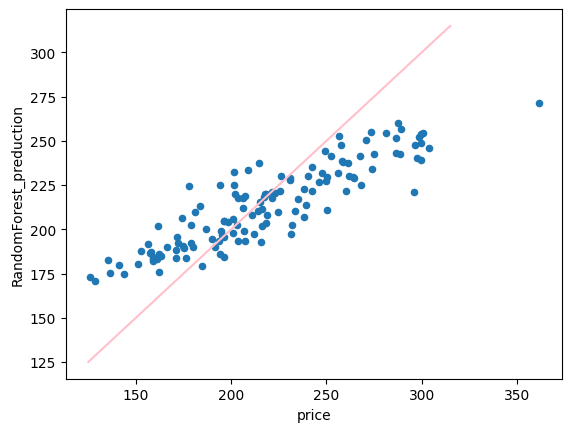

In [149]:
result.plot(kind='scatter',x='price',y='RandomForest_preduction')
xy=pd.Series(np.arange(125,325,10),index=np.arange(125,325,10))
xy.plot(kind='line',color='pink')

In [150]:
MeanSqu_error=pow(result['price']-result['RandomForest_preduction'],2).mean()
print(f'Mean Squared Error:{MeanSqu_error}')
print(f'Root Mean Squared Error:{pow(MeanSqu_error,0.5)}')

Mean Squared Error:761.3454829372713
Root Mean Squared Error:27.59248961107481
